# PHY64 Acoustic Analysis Project Helios and Aaron

In this project, Aaron and I compare the frequency and overtone spectra of several audio recordings. The main goal is to explain quantitatively why different instruments sound different, even when they may play similar notes. We use the Fast Fourier transform to identify the dominant frequencies in each recording and compare the relative amplitudes of the fundamental frequency and overtones.

The files `fakesoon.wav` and `PHY64_strings.wav` are MIDI references. The other recordings are my own playing. By comparing the MIDI spectrums to the real recordings, we can look at how overtone strengths affect the perceived timbre.

## Recordings

The recordings analyzed in this notebook are:

- `realsoon_bb3.wav`: real instrument sound Bb3
- `realsoon_bb4.wav`: real instrument sound Bb4
- `realsoon_f4.wav`: real instrument sound F4
- `fakesoon_bb3.wav`: MIDI instrument sound Bb3
- `fakesoon_bb4.wav`: MIDI instrument sound Bb3
- `fakesoon_f4.wav`: MIDI instrument sound Bb3
- `puretone.wav`: pure sinosoidal wave at Bb3
- `mixtone.wav`: artificially created tone at Bb3

## Method: Fourier Transform and Timbre

To compare the recordings quantitatively, we use the Fourier transform to convert each waveform from the time domain into the frequency domain. The peaks in the frequency spectrum show which frequencies are strongest in the sound. The lowest major peak is usually the fundamental frequency, while higher peaks are overtones or harmonics.

The relative strengths of these overtones are important because they affect timbre. Two instruments can play the same note but sound different if their overtone amplitudes are different.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.fft import fft, ifft, fftfreq
import librosa as lb
%matplotlib widget

def unwind(a):
    return np.roll(a, len(a) // 2)

## Helper Functions

The `Generator` function loads an audio file while keeping its original sampling rate. It calculates the duration of the recording, creates the corresponding time array, finds the Nyquist frequency, and computes the FFT of the waveform.

The `Plotter` function displays the sound in both the time domain and frequency domain. The waveform plot shows how the signal changes over time, while the FFT plot shows the real and imaginary Fourier components as functions of frequency. This lets us see which frequencies contribute strongly to the sound.

The `Amps` function identifies the strongest frequency components in the recording. It converts the complex FFT values into normalized amplitudes, calculates the power spectrum, and returns a table of the largest peaks. Peaks within a chosen frequency range are compared by amplitude, and nearby peaks within a small threshold are treated as the same signal so that one overtone is not counted multiple times.

In [2]:
def Generator(filename):
   Waveform, Sample_Rate = lb.load(filename, sr=None) # keeps the sampling rate of the audio file
   Duration = len(Waveform) / Sample_Rate
   print(f"The duration of the recording is {Duration}")

   Time = np.arange(0, Duration, 1/Sample_Rate)
   Nyquist_Frequency = Sample_Rate / 2
   FFT = fft(Waveform)
   return Waveform, Time, Nyquist_Frequency, FFT, filename

In [3]:
def Plotter(Waveform, Time, Nyquist_Frequency, FFT, Max_Freq, Start_Time, End_Time, filename, 
            Overlay_Info=None):

    fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))

    Sample_Rate = 2 * Nyquist_Frequency
    Freqs = fftfreq(len(FFT), 1 / Sample_Rate)

    FFT_Real = np.real(FFT)
    FFT_Imag = np.imag(FFT)

    ax[0].plot(Time, Waveform, label=filename)

    ## This Overlay section is for the comparison of MIDI recordings and played recordings.

    if Overlay_Info is not None:
        Overlay_Waveform = Overlay_Info[0]
        Overlay_Time = Overlay_Info[1]
        Overlay_Nyquist_Frequency = Overlay_Info[2]
        Overlay_FFT = Overlay_Info[3]
        Overlay_Filename = Overlay_Info[4]

        Overlay_Sample_Rate = 2 * Overlay_Nyquist_Frequency
        Overlay_Freqs = fftfreq(len(Overlay_FFT), 1 / Overlay_Sample_Rate)

        Overlay_FFT_Real = np.real(Overlay_FFT)
        Overlay_FFT_Imag = np.imag(Overlay_FFT)

        ax[0].plot(Overlay_Time, Overlay_Waveform, label=Overlay_Filename, alpha=0.7)

    ax[0].set_title(f"Waveform for {filename}")
    ax[0].set_xlabel("Time (s)")
    ax[0].set_ylabel("Amplitude")
    ax[0].set_xlim(Start_Time, End_Time)
    ax[0].set_ylim(-1, 1)
    ax[0].legend()

    ax[1].plot(unwind(Freqs), unwind(FFT_Real), label=f"Real FFT: {filename}", linewidth=2)
    ax[1].plot(unwind(Freqs), unwind(FFT_Imag), label=f"Imaginary FFT: {filename}", linewidth=1)

    if Overlay_Info is not None:
        ax[1].plot(unwind(Overlay_Freqs), unwind(Overlay_FFT_Real), 
                   label=f"Real FFT: {Overlay_Filename}", linewidth=2, alpha=0.7)
        ax[1].plot(unwind(Overlay_Freqs), unwind(Overlay_FFT_Imag), 
                   label=f"Imaginary FFT: {Overlay_Filename}", linewidth=1, alpha=0.7)

    ax[1].set_title(f"FFT Spectrum for {filename}")
    ax[1].set_xlim(-Max_Freq, Max_Freq)
    ax[1].set_ylim(-6000, 6000)
    ax[1].set_xlabel("Frequency (Hz)")
    ax[1].set_ylabel("FFT Amplitude")
    ax[1].legend()

    for axis in ax:
        axis.grid(True, alpha=0.3)

    fig.tight_layout()

In [4]:
def Amps(Waveform, Time, Nyquist_Frequency, FFT, Number_Peaks=5, Min_Freq=20, Max_Freq=5000, Peak_Separation=15, Overlay_Info=None):
    
    def Get_Rows(Waveform, Nyquist_Frequency, FFT):
        Sample_Rate = 2 * Nyquist_Frequency
        N = len(Waveform)
        Freqs = fftfreq(N, 1 / Sample_Rate)

        # This line computes the normalized amplitude of each frequency component. 
        # The absolute value gives the magnitude of the complex FFT coefficient. 
        # Division by N normalizes for the number of samples, and the factor of 2 
        # accounts for using only the positive-frequency half of the spectrum.
        Amplitude = 2 * np.abs(FFT) / N 
        Power = np.real(FFT * np.conj(FFT))

        # This filters frequencies into the range between Min_Freq and Max_Freq.
        Positive = (Freqs >= Min_Freq) & (Freqs <= Max_Freq)
        Filtered_Freqs = Freqs[Positive]
        Filtered_Amps = Amplitude[Positive]
        Filtered_Power = Power[Positive]

        # This sorts the frequencies by amplitude from largest to smallest.
        sorted_indices = np.argsort(Filtered_Amps)[::-1]
        chosen_indices = []
        
        # This section checks whether the peaks are close to each other within the 
        # peak separation threshold. If not, it is considered a valid peak.
        for i in sorted_indices:
            freq = Filtered_Freqs[i]
            is_new_peak = True

            for chosen_i in chosen_indices:
                chosen_freq = Filtered_Freqs[chosen_i]

                if abs(freq - chosen_freq) < Peak_Separation:
                    is_new_peak = False
                    break

            if is_new_peak:
                chosen_indices.append(i)

            if len(chosen_indices) == Number_Peaks:
                break
        
        strongest_amp = Filtered_Amps[chosen_indices[0]]
        strongest_power = Filtered_Power[chosen_indices[0]]
        rows = []
        
        for rank, i in enumerate(chosen_indices, start=1):
            rows.append({
                "Frequency (Hz)": Filtered_Freqs[i],
                "Amplitude": Filtered_Amps[i],
                "Relative Amplitude": Filtered_Amps[i] / strongest_amp,
                "Power": Filtered_Power[i],
                "Relative Power": Filtered_Power[i] / strongest_power
            })

        return rows

    # This finds the strongest frequency peaks for the played recording.
    played_rows = Get_Rows(Waveform, Nyquist_Frequency, FFT)

    # If there is no fake/overlay recording, the function returns the same type
    # of table as before, using only the played recording.
    if Overlay_Info is None:
        rows = []

        # This formats each peak into a table row.
        for rank, played in enumerate(played_rows, start=1):
            rows.append({
                "Rank": rank,
                "Frequency (Hz)": played["Frequency (Hz)"],
                "Amplitude": played["Amplitude"],
                "Relative Amplitude": played["Relative Amplitude"],
                "Power": played["Power"],
                "Relative Power": played["Relative Power"]
            })

        df = pd.DataFrame(rows)
        return df

    # If an overlay recording is included, this finds the strongest frequency
    # peaks for the fake/computer-generated recording too.
    fake_rows = Get_Rows(Overlay_Info[0], Overlay_Info[2], Overlay_Info[3])

    rows = []

    # This puts the played and fake recordings side by side in the same table.
    # Rank 1 is compared with rank 1, rank 2 with rank 2, and so on.
    for rank in range(Number_Peaks):
        played = played_rows[rank]
        fake = fake_rows[rank]

        rows.append({
            "Rank": rank + 1,

            "Played Frequency (Hz)": played["Frequency (Hz)"],
            "Fake Frequency (Hz)": fake["Frequency (Hz)"],

            "Played Amplitude": played["Amplitude"],
            "Fake Amplitude": fake["Amplitude"],

            "Played Relative Amplitude": played["Relative Amplitude"],
            "Fake Relative Amplitude": fake["Relative Amplitude"],

            "Played Power": played["Power"],
            "Fake Power": fake["Power"],

            "Played Relative Power": played["Relative Power"],
            "Fake Relative Power": fake["Relative Power"]
        })

    # This converts the list of rows into a pandas DataFrame so it displays
    # neatly as a table in the notebook.
    df = pd.DataFrame(rows)
    return df



## Comparison of the Three Played Pitches

### Example 1: Bb3 Recording

First, I analyze the `realsoon_bb3.wav` recording. I use the `Generator` function to load the audio file, create the time array, and compute the FFT. Then I use `Plotter` to show the waveform and FFT spectrum visually. After plotting the signal, I use the `Amps` function to identify the strongest frequency peaks quantitatively. This table helps estimate the fundamental frequency and compare the relative strengths of the overtones.

The duration of the recording is 0.43752834467120183


,Rank,Frequency (Hz),Amplitude,Relative Amplitude,Power,Relative Power
0,1,473.112205,0.450730,1.000000,1.890876e+07,1.000000
1,2,235.413320,0.137309,0.304636,1.754793e+06,0.092803
2,3,943.938844,0.104093,0.230944,1.008499e+06,0.053335
3,4,1179.352164,0.101101,0.224305,9.513499e+05,0.050313
4,5,708.525525,0.062052,0.137671,3.583834e+05,0.018953


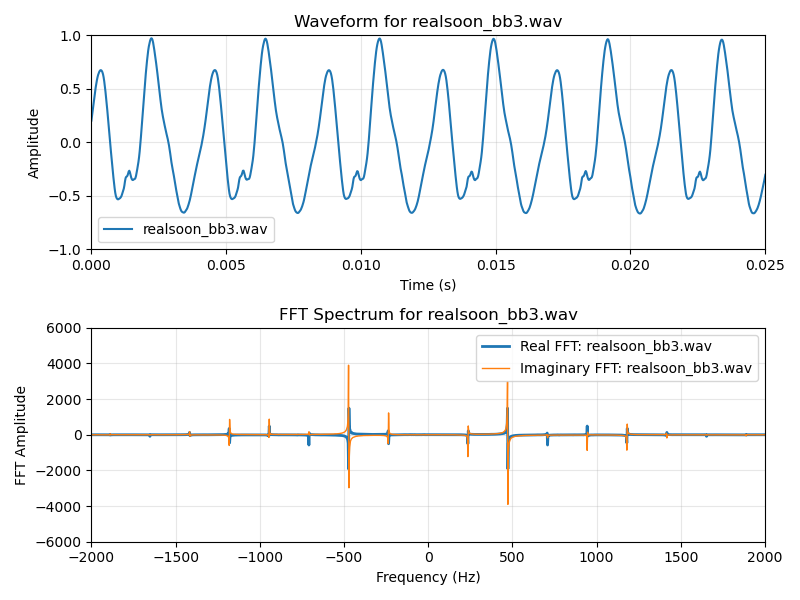

In [5]:
real_bb3 = Generator('realsoon_bb3.wav')
Plotter(real_bb3[0], real_bb3[1], real_bb3[2], real_bb3[3], 2000, 0, 0.025, real_bb3[4])
Amps(real_bb3[0], real_bb3[1], real_bb3[2], real_bb3[3]) 

### Example 2: Bb4 Recording

First, I analyze the `realsoon_bb4.wav` recording. I use the `Generator` function to load the audio file, create the time array, and compute the FFT. Then I use `Plotter` to show the waveform and FFT spectrum visually. After plotting the signal, I use the `Amps` function to identify the strongest frequency peaks quantitatively. This table helps estimate the fundamental frequency and compare the relative strengths of the overtones.

The duration of the recording is 0.43752834467120183


,Rank,Frequency (Hz),Amplitude,Relative Amplitude,Power,Relative Power
0,1,477.683338,0.551159,1.000000,2.827372e+07,1.000000
1,2,955.366675,0.347353,0.630223,1.122977e+07,0.397180
2,3,1433.050013,0.050215,0.091108,2.346932e+05,0.008301
3,4,1910.733351,0.025743,0.046706,6.167828e+04,0.002181
4,5,939.367712,0.021421,0.038866,4.270846e+04,0.001511


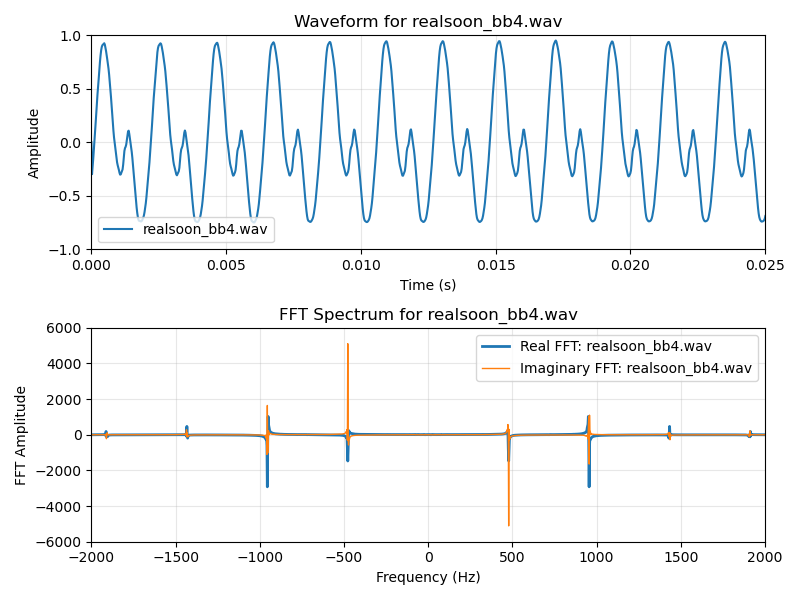

In [6]:
real_bb4 = Generator('realsoon_bb4.wav')
Plotter(real_bb4[0], real_bb4[1], real_bb4[2], real_bb4[3], 2000, 0, 0.025, real_bb4[4])
Amps(real_bb4[0], real_bb4[1], real_bb4[2], real_bb4[3])

### Example 3: F4 Recording

I next analyze the `realsoon_f4.wav` recording using the same Fourier analysis process. I use the `Generator` function to load the audio file, create the time array, and compute the FFT. Then I use `Plotter` to visualize the waveform and FFT spectrum.

After plotting the signal, I use the `Amps` function to identify the strongest frequency peaks. Since F4 is between Bb4 and Bb5, this example helps compare how the overtone spectrum changes for a different pitch.

The duration of the recording is 0.43752834467120183


,Rank,Frequency (Hz),Amplitude,Relative Amplitude,Power,Relative Power
0,1,349.691630,0.550197,1.000000,2.817509e+07,1.000000
1,2,699.383260,0.318956,0.579712,9.468689e+06,0.336066
2,3,1049.074890,0.038286,0.069586,1.364285e+05,0.004842
3,4,1396.480954,0.030958,0.056268,8.920394e+04,0.003166
4,5,2795.247473,0.016482,0.029956,2.528389e+04,0.000897


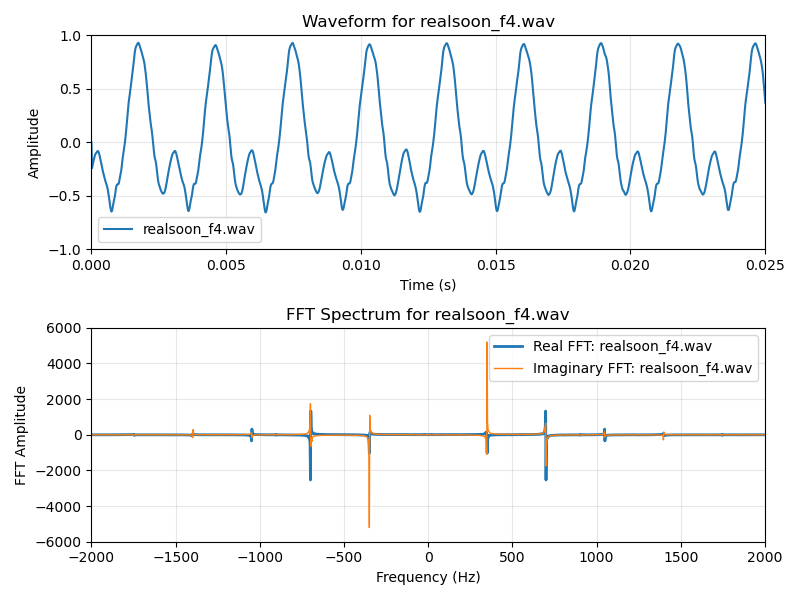

In [7]:
real_f4 = Generator('realsoon_f4.wav')
Plotter(real_f4[0], real_f4[1], real_f4[2], real_f4[3], 2000, 0, 0.025, real_f4[4])
Amps(real_f4[0], real_f4[1], real_f4[2], real_f4[3])

### Analysis

After analyzing the Bb3, F4, and Bb4 recordings separately, I compare them directly using their measured fundamental frequencies and power spectra. The fundamental frequency determines the main perceived pitch, while the power spectrum shows how the signal's energy is distributed across the fundamental and overtones.

The expected pitch ordering is Bb3, then F4, then Bb4. Bb4 should have a fundamental frequency approximately twice that of Bb3 because it is one octave higher. F4 should fall between Bb3 and Bb4.

| Recording | Expected note | Expected frequency (440 Hz for A4) | Measured major frequencies |
|---|---|---|---|
| `realsoon_bb3.wav` | Bb3 | 233 Hz | 473 Hz, 235 Hz, 944 Hz |
| `realsoon_f4.wav` | F4 | 349 Hz | 350 Hz, 700 Hz, 1049 Hz |
| `realsoon_bb4.wav` | Bb4 | 466 Hz | 478 Hz, 955 Hz, 1433 Hz |


To avoid overcounting one broad peak as several different frequencies, I group frequencies that are within about 15 Hz of each other and treat them as the same signal.

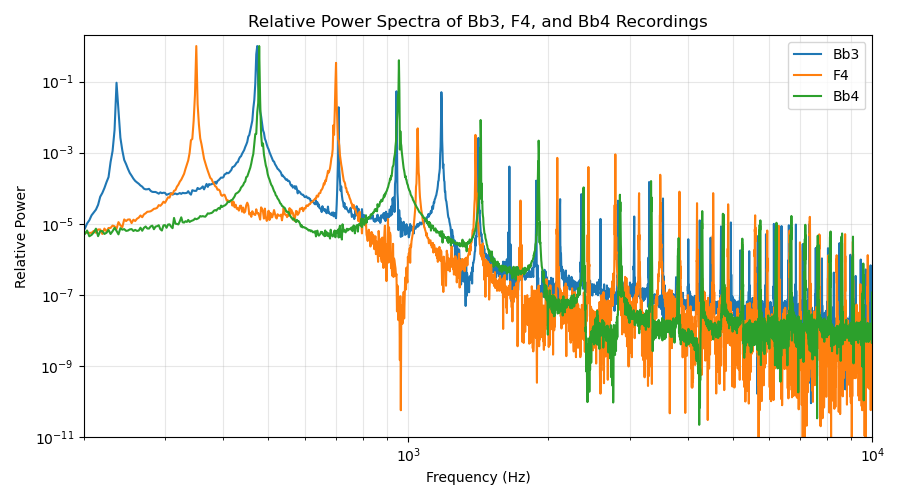

In [8]:
def Power_Spectrum_Info(Info):

    Waveform = Info[0]
    Nyquist_Frequency = Info[2]
    FFT = Info[3]

    Sample_Rate = 2 * Nyquist_Frequency
    Freqs = fftfreq(len(Waveform), 1 / Sample_Rate)
    Power = np.real(FFT * np.conj(FFT))

    Positive = Freqs >= 0

    return Freqs[Positive], Power[Positive]


freq_bb3, power_bb3 = Power_Spectrum_Info(real_bb3)
freq_bb4, power_bb4 = Power_Spectrum_Info(real_bb4)
freq_f4, power_f4 = Power_Spectrum_Info(real_f4)

plt.figure(figsize=(9, 5))

plt.semilogy(freq_bb3, power_bb3 / np.max(power_bb3), label="Bb3")
plt.semilogy(freq_f4, power_f4 / np.max(power_f4), label="F4")
plt.semilogy(freq_bb4, power_bb4 / np.max(power_bb4), label="Bb4")

plt.xscale("log")

plt.xlim(200, 10000)
plt.ylim(10**-11, 2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative Power")
plt.title("Relative Power Spectra of Bb3, F4, and Bb4 Recordings")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("Power_Graph", transparent=True)
plt.show()

### Observations

The main frequencies line up with the expected fundamentals and harmonics of those notes: Bb3 is around 235 Hz, F4 is around 350 Hz, and Bb4 is around 478 Hz. This ordering matches what we would expect musically.

A major observation is that the first two harmonics are very significant in all three recordings. For Bb3, the second harmonic near 473 Hz is actually stronger than the first harmonic near 235 Hz. This means that although the note is perceived as Bb3, a large amount of the sound’s energy is in the octave above the fundamental. The F4 and Bb4 recordings also show strong early harmonics, so the sound is shaped mostly by the fundamental and the first few overtones.

The higher harmonics have much lower relative power compared to the first few peaks. They are still present, but they are not as significant in determining the overall sound. These weaker high-frequency components may still affect the timbre by adding brightness or texture, but most of the acoustic energy is concentrated in the lower harmonics.

One strange feature is the dip in power for the F4 recording around 970 Hz. This is near where we might expect another overtone to appear, but instead the power decreases. We do not have a clear explanation for this from the data alone. It could be caused by the instrument, the room, the microphone, or the way the note was played, but we cannot confidently identify the reason.

## Comparison of the Three MIDI Generated Pitches

In this section, I compare the acoustic properties of computer-generated bassoon tones with the corresponding notes played on a real bassoon. The MIDI bassoon samples for Bb3, Bb4, and F4 provide a controlled, synthesized version of each pitch, allowing for a direct comparison with the recorded performances analyzed earlier. By examining features such as waveform shape and the frequency spectrum and amplitudes, I can observe how closely the computer-generated sounds resemble the real instrument and where they differ. This comparison helps show which aspects of the bassoon’s sound are captured by MIDI synthesis and which qualities of the live instrument are more difficult to reproduce digitally.

### Example 4: Bb3 Recording

For the MIDI Bb3 recording, I compare the computer-generated bassoon sound to the played Bb3 recording. The played Bb3 recording has its strongest peak near 473 Hz, which is the second harmonic, while the fundamental near 235 Hz is weaker. The MIDI Bb3 recording also contains frequencies that fit the Bb3 harmonic series, including peaks near 232 Hz, 464 Hz, 699 Hz, and 931 Hz. However, the MIDI version has its strongest peak near 699 Hz, meaning it emphasizes a higher harmonic more than the played recording does. This shows that both sounds contain the expected Bb3-related harmonics, but the balance of power between them is different.

The duration of the recording is 0.3789569160997732


,Rank,Played Frequency (Hz),Fake Frequency (Hz),Played Amplitude,Fake Amplitude,Played Relative Amplitude,Fake Relative Amplitude,Played Power,Fake Power,Played Relative Power,Fake Relative Power
0,1,473.112205,699.287937,0.450730,0.189318,1.000000,1.000000,1.890876e+07,2.502537e+06,1.000000,1.000000
1,2,235.413320,464.432743,0.137309,0.188611,0.304636,0.996266,1.754793e+06,2.483882e+06,0.092803,0.992545
2,3,943.938844,931.504308,0.104093,0.179047,0.230944,0.945748,1.008499e+06,2.238366e+06,0.053335,0.894439
3,4,1179.352164,232.216371,0.101101,0.112215,0.224305,0.592734,9.513499e+05,8.792240e+05,0.050313,0.351333
4,5,708.525525,1163.720680,0.062052,0.085205,0.137671,0.450062,3.583834e+05,5.069039e+05,0.018953,0.202556


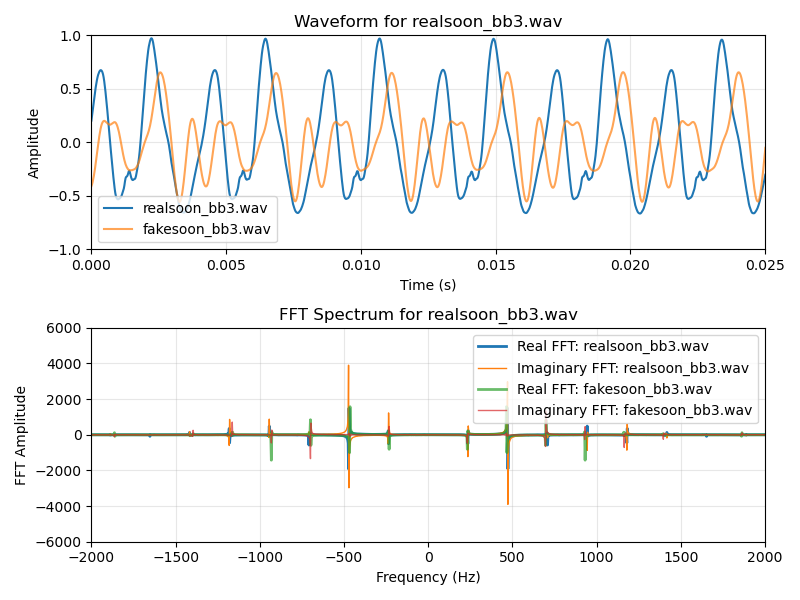

In [9]:
fake_bb3 = Generator("fakesoon_bb3.wav")
Plotter(real_bb3[0], real_bb3[1], real_bb3[2], real_bb3[3], 2000, 0, 0.025, real_bb3[4], Overlay_Info=fake_bb3)
Amps(real_bb3[0], real_bb3[1], real_bb3[2], real_bb3[3], Overlay_Info=fake_bb3)

### Example 5: Bb4 Recording

For the MIDI Bb4 recording, I compare the synthesized bassoon sound to the played Bb4 recording. The played Bb4 recording has its strongest peak near 478 Hz, which matches the expected Bb4 fundamental, and it also has a strong second harmonic near 955 Hz. In the MIDI Bb4 recording, the strongest peak is near 932 Hz, while the fundamental near 466 Hz is weaker. This means that the MIDI version emphasizes the second harmonic more strongly than the fundamental, while the real bassoon recording keeps more power in the fundamental frequency.

The duration of the recording is 0.30038548752834465


,Rank,Played Frequency (Hz),Fake Frequency (Hz),Played Amplitude,Fake Amplitude,Played Relative Amplitude,Fake Relative Amplitude,Played Power,Fake Power,Played Relative Power,Fake Relative Power
0,1,477.683338,932.135578,0.551159,0.454746,1.000000,1.000000,2.827372e+07,9.072211e+06,1.000000,1.000000
1,2,955.366675,466.067789,0.347353,0.201835,0.630223,0.443841,1.122977e+07,1.787181e+06,0.397180,0.196995
2,3,1433.050013,1864.271156,0.050215,0.028342,0.091108,0.062326,2.346932e+05,3.524100e+04,0.008301,0.003884
3,4,1910.733351,1398.203367,0.025743,0.019877,0.046706,0.043710,6.167828e+04,1.733277e+04,0.002181,0.001911
4,5,939.367712,948.780856,0.021421,0.003356,0.038866,0.007380,4.270846e+04,4.941627e+02,0.001511,0.000054


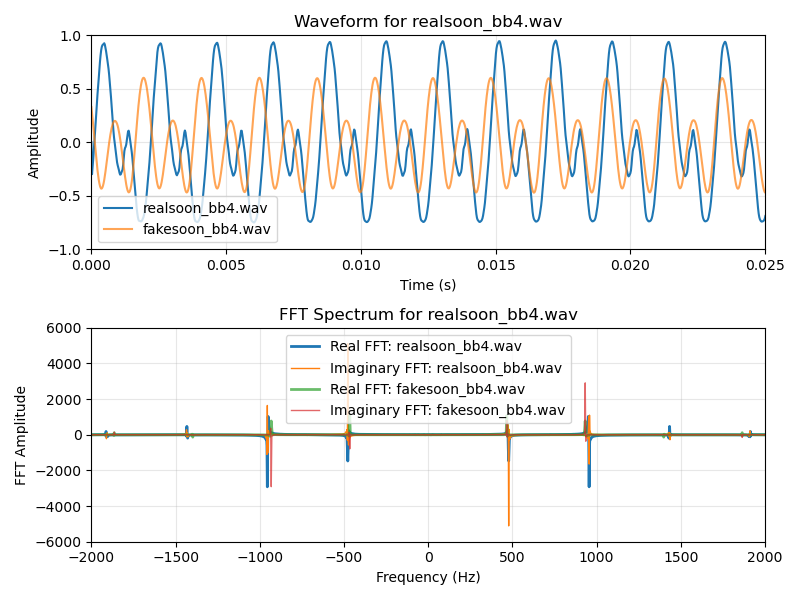

In [10]:
fake_bb4 = Generator("fakesoon_bb4.wav")
Plotter(real_bb4[0], real_bb4[1], real_bb4[2], real_bb4[3], 2000, 0, 0.025, real_bb4[4], Overlay_Info=fake_bb4)
Amps(real_bb4[0], real_bb4[1], real_bb4[2], real_bb4[3], Overlay_Info=fake_bb4)

### Example 6: F4 Recording

For the MIDI F4 recording, I compare the synthesized sound to the played F4 recording. The played F4 recording has its strongest peak near 350 Hz, which matches the expected F4 fundamental, and a strong second harmonic near 699 Hz. In the MIDI F4 recording, the strongest peak is near 699 Hz, while the fundamental near 349 Hz is weaker. This means the MIDI F4 sound emphasizes the octave above the fundamental more strongly than the played bassoon does. The two recordings contain many of the same harmonic frequencies, but their relative strengths are different.

The duration of the recording is 0.20326530612244897


,Rank,Played Frequency (Hz),Fake Frequency (Hz),Played Amplitude,Fake Amplitude,Played Relative Amplitude,Fake Relative Amplitude,Played Power,Fake Power,Played Relative Power,Fake Relative Power
0,1,349.691630,698.594378,0.550197,0.376189,1.000000,1.000000,2.817509e+07,2.842858e+06,1.000000,1.000000
1,2,699.383260,349.297189,0.318956,0.125664,0.579712,0.334045,9.468689e+06,3.172229e+05,0.336066,0.111586
2,3,1049.074890,1047.891566,0.038286,0.115502,0.069586,0.307033,1.364285e+05,2.679944e+05,0.004842,0.094269
3,4,1396.480954,1397.188755,0.030958,0.050149,0.056268,0.133308,8.920394e+04,5.052042e+04,0.003166,0.017771
4,5,2795.247473,718.273092,0.016482,0.011141,0.029956,0.029615,2.528389e+04,2.493266e+03,0.000897,0.000877


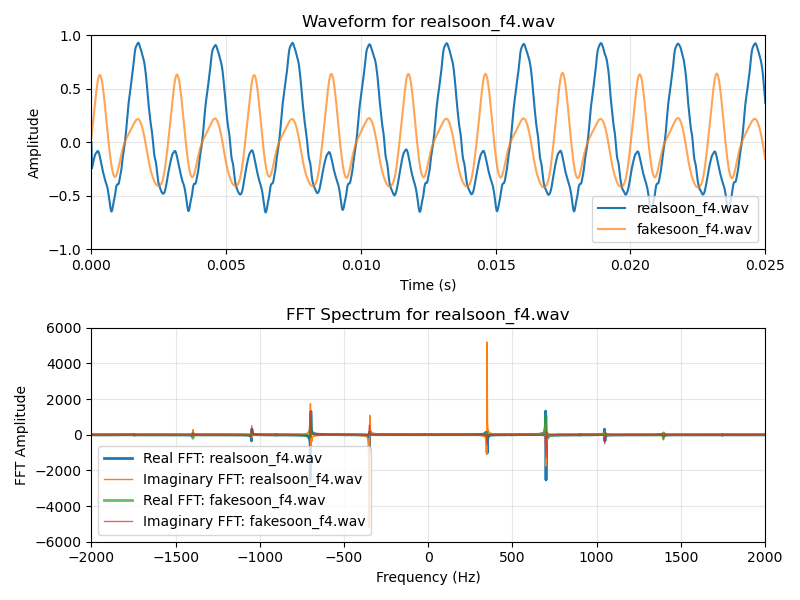

In [11]:
fake_f4 = Generator("fakesoon_f4.wav")
Plotter(real_f4[0], real_f4[1], real_f4[2], real_f4[3], 2000, 0, 0.025, real_f4[4], Overlay_Info=fake_f4)
Amps(real_f4[0], real_f4[1], real_f4[2], real_f4[3], Overlay_Info=fake_f4)

### Analysis

In this section, I analyze the computer-generated bassoon recordings for Bb3, F4, and Bb4. These MIDI recordings are compared with the played bassoon recordings to see how closely the synthesized sound matches the real instrument. The FFT spectra show that the MIDI recordings contain many of the expected harmonic frequencies, but the relative strength of those frequencies is different from the played recordings.

| Recording | Strongest Peak (Hz) | Important Other Peaks (Hz) | Main Observation |
|---|---:|---|---|
| MIDI Bb3 | 699 | 464, 931, 232, 1164 | The MIDI Bb3 contains the expected Bb3 harmonic series, but it emphasizes the third harmonic near 699 Hz slightly more than the lower harmonics. |
| MIDI F4 | 699 | 349, 1048, 1397 | The MIDI F4 emphasizes the second harmonic near 699 Hz more strongly than the fundamental near 349 Hz. |
| MIDI Bb4 | 932 | 466, 1864, 1398 | The MIDI Bb4 emphasizes the second harmonic near 932 Hz, while the fundamental near 466 Hz is present but weaker. |

The table shows that the computer-generated bassoon sounds have clear harmonic structures that match the expected pitches of Bb3, F4, and Bb4. However, the MIDI recordings often place the greatest power in a higher harmonic instead of the fundamental frequency.

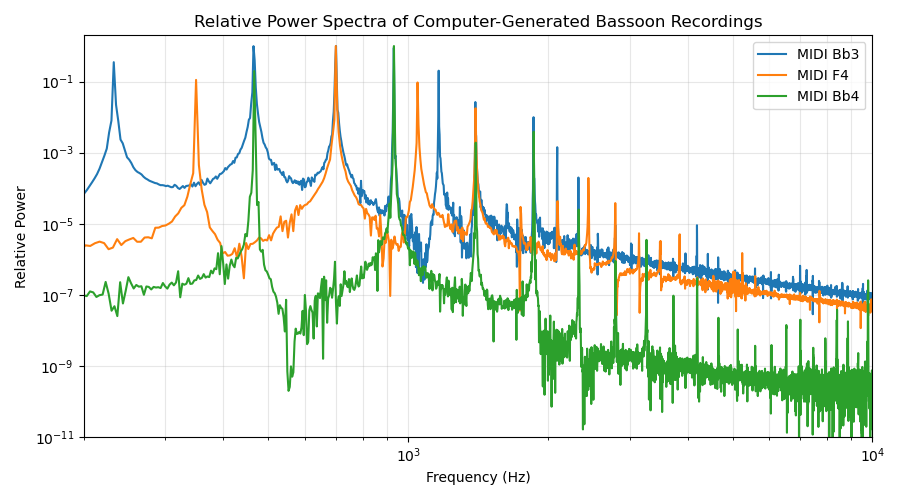

In [12]:
fake_freq_bb3, fake_power_bb3 = Power_Spectrum_Info(fake_bb3)
fake_freq_f4, fake_power_f4 = Power_Spectrum_Info(fake_f4)
fake_freq_bb4, fake_power_bb4 = Power_Spectrum_Info(fake_bb4)

plt.figure(figsize=(9, 5))

plt.semilogy(fake_freq_bb3, fake_power_bb3 / np.max(fake_power_bb3), label="MIDI Bb3")
plt.semilogy(fake_freq_f4, fake_power_f4 / np.max(fake_power_f4), label="MIDI F4")
plt.semilogy(fake_freq_bb4, fake_power_bb4 / np.max(fake_power_bb4), label="MIDI Bb4")

plt.xscale("log")

plt.xlim(200, 10000)
plt.ylim(10**-11, 2)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Relative Power")
plt.title("Relative Power Spectra of Computer-Generated Bassoon Recordings")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("Power_fGraph", transparent=True)
plt.show()


### Observations

For MIDI Bb3, the strongest peak is near 699 Hz, which is close to the third harmonic of Bb3. The peaks near 232 Hz, 464 Hz, and 931 Hz also fit the expected harmonic pattern, but they are not all equally strong. Compared with the played Bb3 recording, where the second harmonic near 473 Hz is strongest, the MIDI version distributes its power differently across the harmonic series.

For MIDI F4, the strongest peak is near 699 Hz, which is the second harmonic of F4. The fundamental near 349 Hz is still present, but it is weaker than the second harmonic. In the played F4 recording, the fundamental near 350 Hz is strongest, so the MIDI version gives the sound a different harmonic balance.

For MIDI Bb4, the strongest peak is near 932 Hz, which is the second harmonic of Bb4. The fundamental near 466 Hz is present, but it has much less power than the second harmonic. In the played Bb4 recording, the fundamental near 478 Hz is strongest, so the real bassoon sound is more centered on the fundamental than the MIDI version.

Overall, the MIDI bassoon recordings reproduce the basic harmonic pattern of the intended notes, but they do not match the exact balance of power in the played bassoon recordings. The MIDI tones often emphasize the second or third harmonic more strongly, while the real recordings show a different distribution between the fundamental and early harmonics.

## Pure Tone and Mixed Tone Demonstration

To help demonstrate the effect of harmonics, we generated two simple artificial sounds: a pure tone and a mixed tone. The pure tone was created using a single sine wave at one frequency. Because it contains only one frequency component, it sounds very smooth and simple, without much timbral complexity.

The mixed tone was created by adding several sine waves together at harmonic-related frequencies. These added harmonics change the shape of the waveform and make the sound more complex. Even though the fundamental frequency is still present, the extra harmonics affect the tone quality, making it sound richer than the pure sine wave.

This comparison is useful for the presentation because it makes the role of harmonics audible. Instead of only looking at frequency spectra, we can hear how adding harmonics changes the perceived sound while keeping the same basic pitch.


In [13]:
"""
This is the example code from the SCIPY documentation on how to write a .WAV file, 
which I used to generate my own pure tone and late a mix of tones for example purposes.
"""

from scipy.io.wavfile import write
import numpy as np
samplerate = 44100; fs = 233
t = np.linspace(0., 1., samplerate)
amplitude = np.iinfo(np.int16).max
data = amplitude * np.sin(2. * np.pi * fs * t)
write("puretone.wav", samplerate, data.astype(np.int16))

In [14]:
from scipy.io.wavfile import write
import numpy as np
samplerate = 44100
t = np.linspace(0., 1., samplerate)
amplitude = 2000
data = amplitude * ( 10*np.sin(2. * np.pi * 233 * t) + np.sin(2. * np.pi * 233*2 * t) + np.sin(2. * np.pi * 233*3/2 * t) + np.sin(2. * np.pi * 233 * 5/4 * 2 * t))
write("mixtone.wav", samplerate, data.astype(np.int16))

## Summary and Reflection

Through this project, we learned several practical skills, such as how to read and write `.wav` files, or how to find and adapt code to do so. We also learned how to use the Makerspace AV studio equipment. In addition, we gained a broader understanding of how fallible any process can be. While recording the GarageBand MIDI notes, we realized that what GarageBand labeled as Bb3, which we initially thought it might have labeled as Bb2, sou ded familiar to Helios as Bb4. At first, we followed Helios's convention, but after examining the FFT, we recognized that either there was an unexplained octave undertone or we were off by an octave. We concluded that the latter was more likely.

Although this was a relatively minor correction, it demonstrated the importance of understanding our work and having some level of trust in the results it produces. This does not mean blindly trusting everything we code, but rather recognizing that errors can come from our inputs as well as from the code itself. Sometimes, the results can point us toward mistakes in our assumptions.

We encountered a similar lesson when copying code from class produced an incorrect result. Fixing the issue required us to understand what the code was actually doing, especially the role of each function input. Overall, this project taught us the importance of maintaining a working understanding of each part of our process and how those parts interact to produce our results.

## Appendices

### Appendix I: Individual Power Spectra

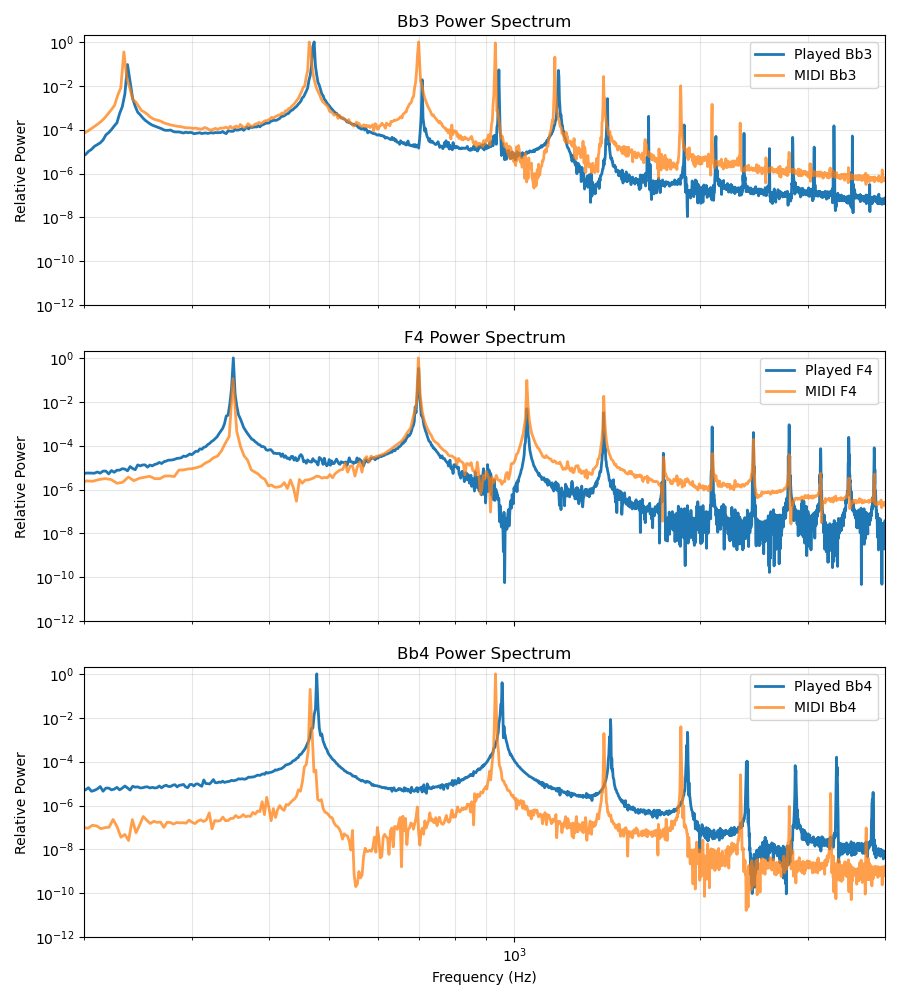

In [15]:
fig, ax = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

ax[0].plot(freq_bb3, power_bb3 / np.max(power_bb3), label="Played Bb3", linewidth=2)
ax[0].plot(fake_freq_bb3, fake_power_bb3 / np.max(fake_power_bb3), label="MIDI Bb3", linewidth=2, alpha=0.75)
ax[0].set_title("Bb3 Power Spectrum")
ax[0].set_ylabel("Relative Power")
ax[0].legend()
ax[0].grid(True, which="both", alpha=0.3)

ax[1].plot(freq_f4, power_f4 / np.max(power_f4), label="Played F4", linewidth=2)
ax[1].plot(fake_freq_f4, fake_power_f4 / np.max(fake_power_f4), label="MIDI F4", linewidth=2, alpha=0.75)
ax[1].set_title("F4 Power Spectrum")
ax[1].set_ylabel("Relative Power")
ax[1].legend()
ax[1].grid(True, which="both", alpha=0.3)

ax[2].plot(freq_bb4, power_bb4 / np.max(power_bb4), label="Played Bb4", linewidth=2)
ax[2].plot(fake_freq_bb4, fake_power_bb4 / np.max(fake_power_bb4), label="MIDI Bb4", linewidth=2, alpha=0.75)
ax[2].set_title("Bb4 Power Spectrum")
ax[2].set_xlabel("Frequency (Hz)")
ax[2].set_ylabel("Relative Power")
ax[2].legend()
ax[2].grid(True, which="both", alpha=0.3)

for axis in ax:
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlim(200, 4000)
    axis.set_ylim(10**-12, 2)

plt.tight_layout()
plt.savefig("Power_Comp_Graph", transparent=True)
plt.show()

### Appendix II: Funky Synth Analysis

The duration of the recording is 0.9032879818594104


,Rank,Frequency (Hz),Amplitude,Relative Amplitude,Power,Relative Power
0,1,349.833061,0.054870,1.000000,1.194379e+06,1.000000
1,2,232.483996,0.037749,0.687963,5.652908e+05,0.473292
2,3,467.182126,0.030120,0.548929,3.598939e+05,0.301323
3,4,582.317058,0.025208,0.459420,2.520938e+05,0.211067
4,5,699.666123,0.022422,0.408630,1.994352e+05,0.166978


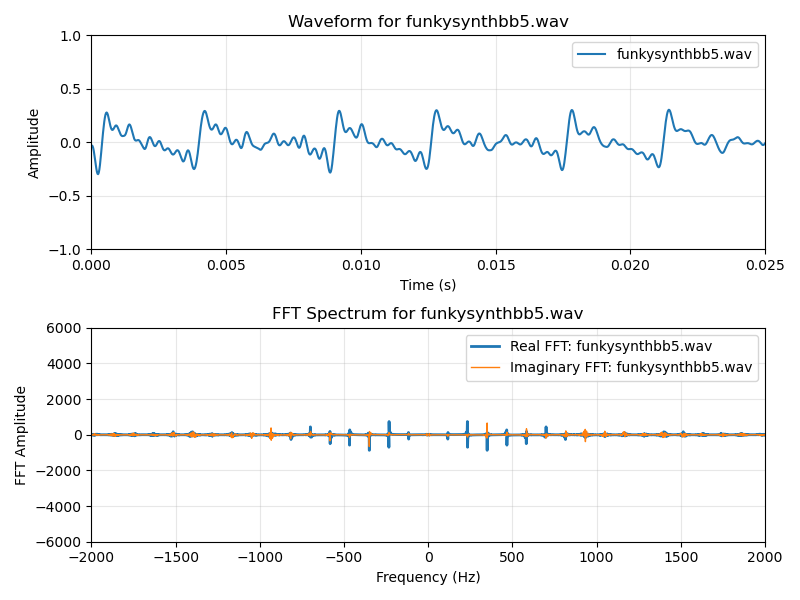

In [16]:
filename_7 = 'funkysynthbb5.wav'
Info_7 = Generator(filename_7)
Plotter(Info_7[0], Info_7[1], Info_7[2], Info_7[3], 2000, 0, 0.025, Info_7[4])
Amps(Info_7[0], Info_7[1], Info_7[2], Info_7[3])